# Linear Regression

Linear Regression is a **supervised machine learning algorithm** used to predict continuous numerical values.

It models the relationship between input variables and output variables using a linear equation.

---

# Types of Linear Regression

## 1. Simple Linear Regression

Simple Linear Regression has:

- one input variable
- one output variable

Example:

```text
GPA → Salary
```

It tries to find a straight-line relationship between the two variables.

---

## 2. Multiple Linear Regression

Multiple Linear Regression has:

- more than one input variable
- one output variable

Example:

```text
GPA, Gender, Skills → Salary
```

Multiple factors together are used to predict the output.

---

## 3. Polynomial Linear Regression

Polynomial Regression is used when the relationship between data points is not linear.

Instead of fitting a straight line, it fits a curve to the data.

This helps model more complex relationships between input and output variables.

# Simple Linear Regression

First, we plot the data.

- X-axis → GPA  
- Y-axis → Salary  

You might observe that real-world data generally follows a linear trend, but it is not perfectly linear.

The goal is to find the **best fit line** that represents the relationship between the variables.

Linear Regression helps find this best fit line.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  

In [72]:
df = pd.read_csv("./dataset/placement.csv")

In [73]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


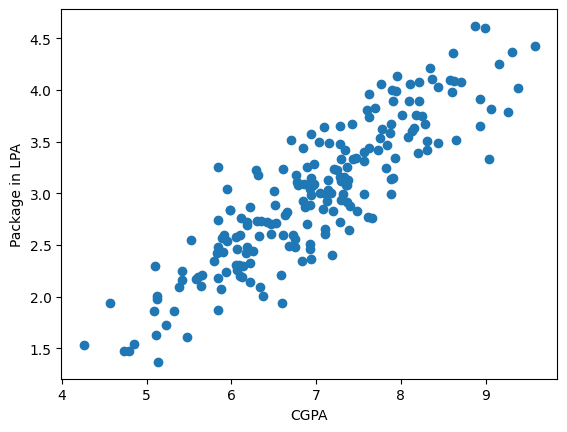

In [74]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package in LPA')
plt.show()

In [75]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [76]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=2
)

In [77]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [78]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [79]:
lr.predict(X_test.iloc[1].values.reshape(1,1))

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.09324469])

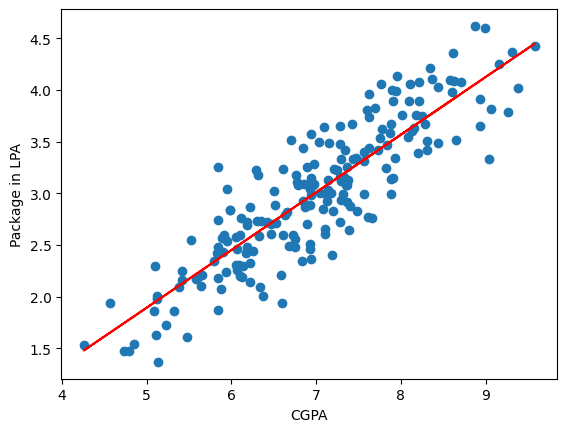

In [80]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color="red")
plt.xlabel('CGPA')
plt.ylabel('Package in LPA')
plt.show()

In [81]:
print(f"Slope = {lr.coef_}")
print(f"Intercept = {lr.intercept_}")

Slope = [0.55795197]
Intercept = -0.8961119222429144


### Maths behind Simple Linear Regression

We are finding **m** and **b** for the best fit line:

$$
y = mx + b
$$

In linear regression:

- **m**: weight (how much a unit change in x affects y)  
- **b**: offset (value when input is zero)

---

There are two ways of calculating these values:

---

## 1) Closed Form Solution (Direct Formula)

Also known as **Ordinary Least Squares (OLS)**.

- Used for low-dimensional data  
- Scikit-learn uses this approach for simple cases  

Formula for slope:

$$
m = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

Where:

- \( \bar{x} \) = mean of x  
- \( \bar{y} \) = mean of y  

Intercept:

$$
b = \bar{y} - m\bar{x}
$$

---

## 2) Non Closed Form (Approximation)

This method uses **Gradient Descent**.

- Used for higher-dimensional data  
- Iteratively updates m and b to minimize error  

# Closed Form Solution (Least Squares)

Our goal is to minimize the error.

![](./images/img1.png)

---

## Step 1: Define Error

Let the total error be:

$$
E = d_1 + d_2 + d_3 + \dots + d_n
$$

---

## Step 2: Square the Errors

We square the errors to remove sign cancellation (positive/negative effects cancel out in simple sum):

$$
E = d_1^2 + d_2^2 + d_3^2 + \dots
$$

$$
E = \sum_{i=1}^{n} d_i^2
$$

---

We do not use absolute value because:

- derivative is not smooth  
- harder to optimize mathematically  
- squaring is easier for calculus  

---

## Step 3: Substitute Error Term

Each error is:

$$
d_i = y_i - \hat{y}_i
$$

So:

$$
E = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

---

## Step 4: Linear Model Substitution

We know:

$$
\hat{y}_i = mx_i + b
$$

So the final error function becomes:

$$
E(m,b)= \sum_{i=1}^{n} (y_i - mx_i - b)^2
$$

---

Changing values of \(m\) and \(b\) changes this function.

We need values of \(m\) and \(b\) such that \(E\) is minimum.

The minimum of a function occurs where the first derivative is zero.

So we calculate partial derivatives:

$$
\frac{\partial E}{\partial b} = 0
$$

$$
\frac{\partial E}{\partial m} = 0
$$

---

## Step 5: Derivative w.r.t. b

Start with:

$$
E = \sum_{i=1}^{n} (y_i - mx_i - b)^2
$$

Differentiate w.r.t. \(b\):

$$
\frac{\partial E}{\partial b}
= \sum_{i=1}^{n} 2(y_i - mx_i - b)(-1)
$$

$$
= -2 \sum_{i=1}^{n} (y_i - mx_i - b)
$$

Set to zero:

$$
\sum_{i=1}^{n} (y_i - mx_i - b) = 0
$$

---

## Step 6: Derivative w.r.t. m

Differentiate w.r.t. \(m\):

$$
\frac{\partial E}{\partial m}
= \sum_{i=1}^{n} 2(y_i - mx_i - b)(-x_i)
$$

$$
= -2 \sum_{i=1}^{n} x_i (y_i - mx_i - b)
$$

Set to zero:

$$
\sum_{i=1}^{n} x_i (y_i - mx_i - b) = 0
$$

---

## Final Result

Solving these two equations together gives the closed-form solution:

### Slope (m)
$$
m = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

### Intercept (b)
$$
b = \bar{y} - m\bar{x}
$$

---

## Final Model

$$
y = mx + b
$$

In [93]:
class LinearRegression:
    def __init__(self):
        self.m = None
        self.b = None
    
    def fit(self, X_train, y_train):
        num = 0
        den = 0

        x_mean = X_train.mean()
        y_mean = y_train.mean()

        for i in range(X_train.shape[0]):
            num += (X_train[i] - x_mean) * (y_train[i] - y_mean)
            den += (X_train[i] - x_mean) * (X_train[i] - x_mean)

        self.m = num / den
        self.b = y_mean - (self.m * x_mean)

        print(self.m, self.b)

        
    def predict(self, X_test):
        return self.m * X_test + self.b

In [94]:
import pandas as pd
import numpy as np

In [95]:
df = pd.read_csv("./dataset/placement.csv")


In [96]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [97]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state= 2)

In [99]:
lr = LinearRegression()
lr.fit(X_train, y_train)

0.5579519734250721 -0.8961119222429152


In [100]:
lr.predict(X_test[0])

np.float64(3.891116009744203)

### Regression Metrics

---

## 1) MAE (Mean Absolute Error)

It is given by:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

### Advantages:
- Gives error in same unit as \(y\)
- Robust to outliers

### Disadvantages:
- Not differentiable at 0

---

## 2) MSE (Mean Squared Error)

It is given by:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

### Advantages:
- Differentiable → used in optimization/loss functions

### Disadvantages:
- Magnifies outliers
- Harder to interpret due to squared units

---

## 3) RMSE (Root Mean Squared Error)

$$
RMSE = \sqrt{MSE}
$$

### Advantages:
- Same unit as target variable

### Disadvantages:
- Sensitive to outliers

---

## 4) R² Score (Goodness of Fit / Coefficient of Determination)

It defines how well the model is performing.

We compare the regression model with a baseline model that always predicts the mean.

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

Where:

- \(SS_{res} = \sum (y_i - \hat{y}_i)^2\) (residual error)
- \(SS_{tot} = \sum (y_i - \bar{y})^2\) (mean-based error)

So:

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

- \(R^2 = 0\): model is same as mean predictor  
- \(R^2 = 1\): perfect regression line  
- \(R^2 < 0\): model is worse than mean predictor  

Example interpretation:
- \(R^2 = 0.8\) means 80% of the variance in \(y\) is explained by \(x\)

---

## 5) Adjusted R²

R² has a flaw: it always increases when we add more features, even if they are irrelevant.

Adjusted R² fixes this by penalizing unnecessary features.

$$
R^2_{adj} = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}
$$

Where:
- \(n\) = number of samples
- \(k\) = number of independent features

### Key Idea:
It reduces the effect of irrelevant features and gives a more honest evaluation of model performance in multiple regression.

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [102]:
y_pred = lr.predict(X_test)

In [103]:
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

r2 = r2_score(y_test, y_pred)
print("R2_Score", r2)

# Adjusted R2
n = X_test.shape[0]

# if X is 1D (single feature), p = 1
p = X_test.shape[1] if len(X_test.shape) > 1 else 1

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R2_Score", adjusted_r2)

MAE 0.2884710931878174
MSE 0.12129235313495523
RMSE 0.3482705171773161
R2_Score 0.7807301475103842
Adjusted R2_Score 0.7749598882343417


# Multiple Linear Regression

It is used when we have multiple input columns.

Example:
- GPA, IQ → Salary

It fits a **plane** in 3D space.

![](./images/img2.png)

For higher dimensions (nD), we fit a **hyperplane**.

---

## Model Equation

Our goal is to solve:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2
$$

Where:

- \( \beta_1 \): change in \(y\) for a unit change in \(x_1\)
- \( \beta_2 \): change in \(y\) for a unit change in \(x_2\)
- \( \beta_0 \): offset (bias term)

---

## General Form

We extend this idea to \(n\) dimensions:

$$
y = \beta_0 + \sum_{i=1}^{n} \beta_i x_i
$$

In [105]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [109]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [110]:
df.head()

,feature1,feature2,target
0,1.445590,-1.825273,90.316743
1,0.146910,1.863634,140.893195
2,-0.347859,-1.089686,-78.518035
3,0.187394,-1.821593,6.137908
4,0.399743,-0.913214,23.631896


In [115]:
fig = px.scatter_3d(df, x="feature1", y="feature2", z="target")
fig.show(renderer="browser")

![](./images/img3.png)

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=3)

In [118]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [119]:
y_pred = lr.predict(X_test)

In [121]:
print(f"MAE = {mean_absolute_error(y_test,y_pred)}")
print(f"MSE = {mean_squared_error(y_test,y_pred)}")
print(f"R2_Score = {r2_score(y_test,y_pred)}")

MAE = 38.219864063480586
MSE = 2043.9359586832798
R2_Score = 0.6287607296083443


In [122]:
lr.coef_

array([40.70973489, 19.48017054])

In [123]:
lr.intercept_

np.float64(-0.82590971774757)

### Maths Behind Multiple Linear Regression

We need to find:

$$
\beta_0, \beta_1, \beta_2, \dots, \beta_n
$$

Suppose we have features:

$$
X_1, X_2, X_3, \dots
$$

and target:

$$
Y
$$

The prediction equation is:

$$
\hat{Y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n
$$

---

## Matrix Form

Suppose we have 100 rows and 3 features:

$$
\begin{bmatrix} 
\hat{Y}_1 \\ 
\hat{Y}_2 \\ 
\vdots \\ 
\hat{Y}_{100} 
\end{bmatrix}
=
\begin{bmatrix} 
1 & X_{11} & X_{12} & X_{13} \\ 
1 & X_{21} & X_{22} & X_{23} \\ 
\vdots & \vdots & \vdots & \vdots \\ 
1 & X_{100,1} & X_{100,2} & X_{100,3} 
\end{bmatrix}
\begin{bmatrix} 
\beta_0 \\ 
\beta_1 \\ 
\beta_2 \\ 
\beta_3 
\end{bmatrix}
$$

---

Suppose we generalize to:

- \(n\) rows
- \(m\) features

Then:

$$
\begin{bmatrix} 
\hat{Y}_1 \\ 
\hat{Y}_2 \\ 
\vdots \\ 
\hat{Y}_n 
\end{bmatrix}
=
\begin{bmatrix} 
1 & X_{11} & X_{12} & \dots & X_{1m} \\ 
1 & X_{21} & X_{22} & \dots & X_{2m} \\ 
\vdots & \vdots & \vdots & \ddots & \vdots \\ 
1 & X_{n1} & X_{n2} & \dots & X_{nm} 
\end{bmatrix}
\begin{bmatrix} 
\beta_0 \\ 
\beta_1 \\ 
\beta_2 \\ 
\vdots \\ 
\beta_m 
\end{bmatrix}
$$

---

So:

$$
\hat{Y} = X\beta
$$

---

## Error Matrix

We define the error matrix:

$$
e = Y - \hat{Y}
$$

$$
e =
\begin{bmatrix}
Y_1 - \hat{Y}_1 \\
Y_2 - \hat{Y}_2 \\
\vdots \\
Y_n - \hat{Y}_n
\end{bmatrix}
$$

---

## Error Function

The error function is:

$$
E = e^T e
$$

This reduces to:

$$
E = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Substituting:

$$
E = Y^T Y - Y^T X\beta - (X\beta)^T Y + (X\beta)^T X\beta
$$

---

Since:

$$
Y^T X\beta = (X\beta)^T Y
$$

we get:

$$
E = Y^T Y - 2Y^T X\beta + \beta^T X^T X \beta
$$

---

## Derivative w.r.t. Beta

We calculate:

$$
\frac{dE}{d\beta}
=
\frac{d}{d\beta}
\left[
Y^T Y
- 2Y^T X\beta
+ \beta^T X^T X\beta
\right]
= 0
$$

Solving gives:

$$
\beta = (X^T X)^{-1} X^T Y
$$

---

# Least Squares Method

This method is called the **Method of Least Squares**.

---

# Alternative Method: Gradient Descent

Another method is **Gradient Descent**.

Gradient Descent is preferred for very large datasets because the Least Squares method becomes computationally expensive for high-dimensional data.

```markdown
> **Important:**  
> In Scikit-learn:
>
> - `LinearRegression` uses the **Least Squares (Closed Form Solution)** method  
> - `SGDRegressor` uses **Gradient Descent (Stochastic Gradient Descent)**
```


In [124]:
import numpy as np
from sklearn.datasets import load_diabetes

In [125]:
X , y = load_diabetes(return_X_y=True)

In [129]:
#Using Sklearn's Linear Regression
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [130]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [131]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [132]:
y_pred = reg.predict(X_test)

In [133]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.439933866156897

In [134]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [135]:
reg.intercept_

np.float64(151.88331005254167)

In [136]:
#Making our own Linear Regression Class
class MultipleLinearRegression():
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        
        # calcuate the coeffs
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
    
    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred

In [137]:
lr = MultipleLinearRegression()

In [138]:
lr.fit(X_train,y_train)

In [139]:
y_pred = lr.predict(X_test)

In [140]:
r2_score(y_test,y_pred)

0.4399338661568961

In [141]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [142]:
lr.intercept_

np.float64(151.8833100525417)